In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("../data/tanzania.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [3]:
df["Country"] = "Tanzania"
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

In [4]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27,3
4104,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28,3
4105,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29,3
4106,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30,3


In [5]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)

Duplicate rows found: 0


In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


In [7]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [8]:
missing_df[missing_df["Missing %"] > 5]

,Missing Count,Missing %


In [9]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN",
        "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)

outliers = np.abs(z_scores) > 3

print("Outlier rows:", outliers.any(axis=1).sum())

Outlier rows: 97


I choose to CAP outliers instead of removing them because climate extremes are meaningful and part of real weather variability. This preserves time-series integrity

In [10]:
for col in cols:
    mean = df[col].mean()
    std = df[col].std()

    upper = mean + 3 * std
    lower = mean - 3 * std
    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

In [11]:


df[cols].head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,27.56,29.52,26.22,7.24,80.97,4.68,6.01
1,27.59,29.99,25.92,3.40,79.63,4.48,5.28
2,27.47,29.29,26.25,7.17,80.02,4.91,5.99
3,27.28,29.17,25.96,16.07,81.78,4.88,6.07
4,26.68,27.83,25.84,18.83,82.99,4.17,5.98


In [12]:
df = df.sort_values("Date")
df = df.ffill()

In [13]:
df = df.dropna(thresh=int(0.7 * df.shape[1]))

In [14]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802458,29.163275,25.038371,4.125363,3.420823,77.128820,4.104729,5.188300,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.826257,25.410000,20.431810,0.940000,0.000000,61.916535,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.710000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.375000,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.310000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.276957,28.010000,7.590000,27.752097,91.100000,7.284779,8.834303,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325279,1.370457,1.534693,1.102831,6.002178,5.068026,1.057637,1.211287,0.284461,1.881741,NaN,3.477046


In [15]:
df.to_csv("../data/tanzania_clean.csv", index=False)

Monthly Average Temperature (Trend Over Time)

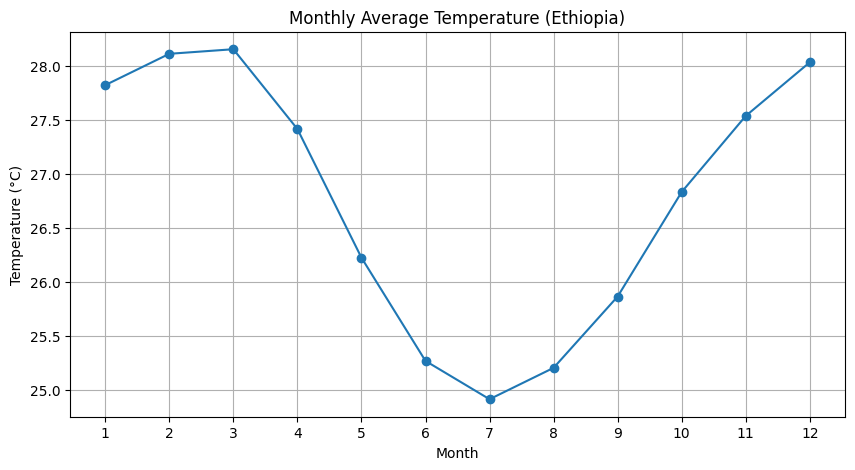

In [16]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (Ethiopia)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

# Monthly Rainfall Pattern

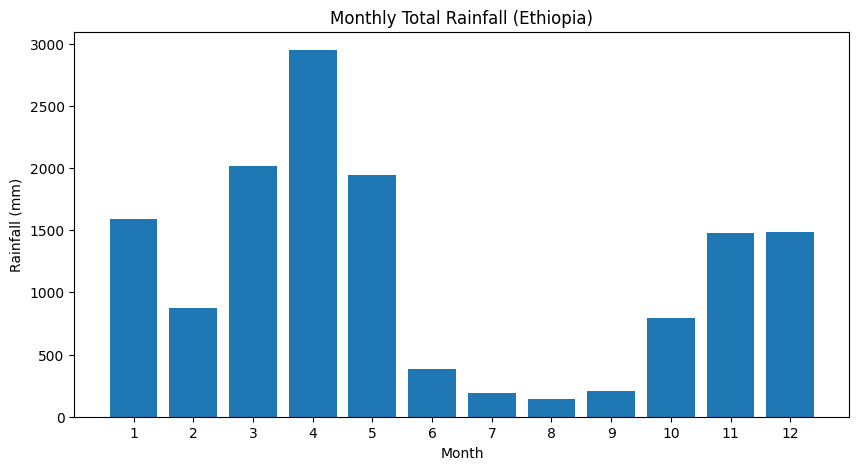

In [17]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(10,5))
plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Total Rainfall (Ethiopia)")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.xticks(range(1,13))
plt.show()

# Correlation Heatmap

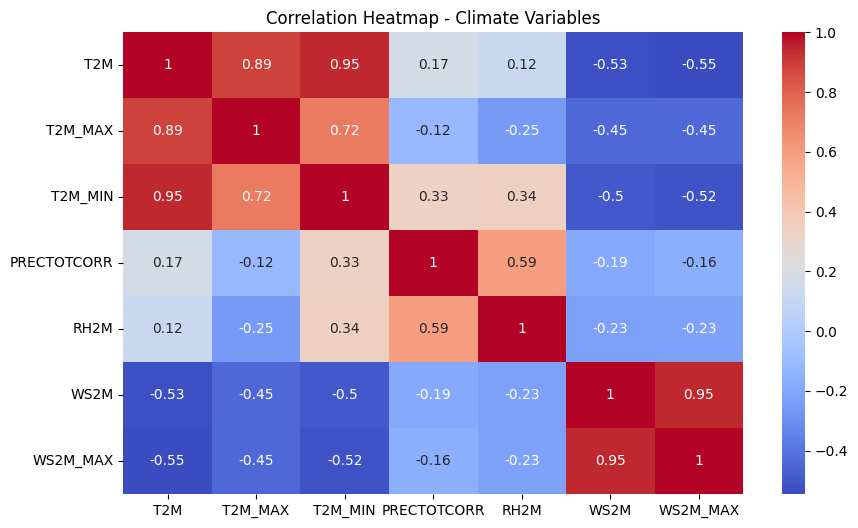

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Climate Variables")
plt.show()

# Scatter Plot (Temperature vs Humidity)

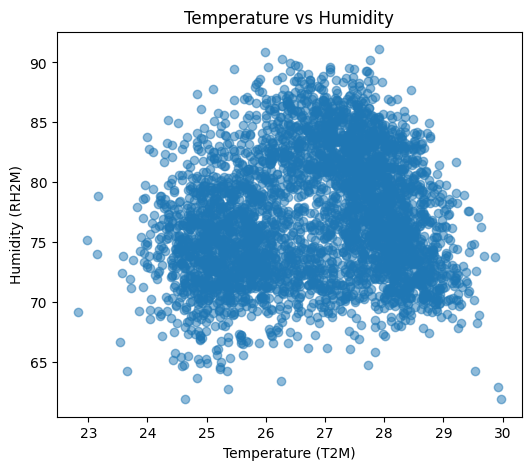

In [19]:
plt.figure(figsize=(6,5))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

# Wind vs Temperature Range

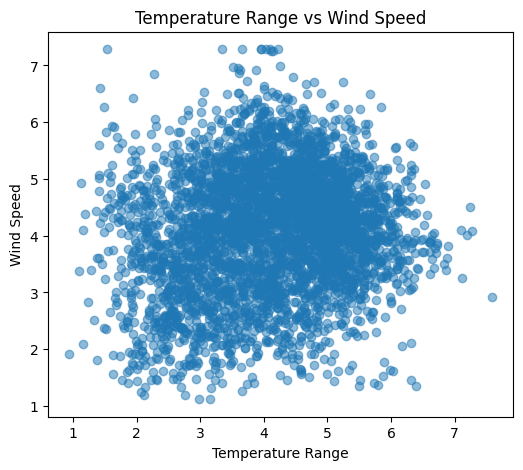

In [20]:
plt.figure(figsize=(6,5))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.show()

# Rainfall Distribution (Skew Check)

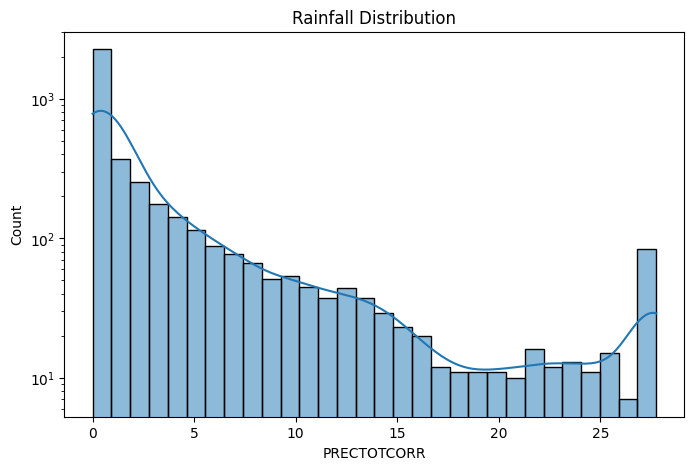

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True)
plt.title("Rainfall Distribution")
plt.yscale("log")  # helps if skewed
plt.show()